# National Job Market Predictor (Model-Ready CSV)

This notebook uses the prebuilt `annual_wage_model_data_2010_2024.csv` file to train and evaluate the same occupation-level forecasting model from the original notebook. The raw BLS/OEWS file discovery, cleaning, schema standardization, and target-building steps are skipped because they have already been saved in the CSV.

**Model choice:** Random Forest regression is used as the main model. It predicts each occupation's next-year employment and annual mean wage from the current year's occupation, employment, annual wage, and SOC-code features.

## Report Summary

### Data Used

The notebook reads the model-ready `annual_wage_model_data_2010_2024.csv` file. That CSV already contains the cleaned annual-wage panel, one-year-ahead targets, SOC-code features, log transforms, employment share, and train/holdout split labels.

### Preprocessing Skipped

The original notebook's raw-file preprocessing is not repeated here. This version does not discover BLS/OEWS source files, standardize raw column names, remove hourly wage fields, filter occupation groups, or create lagged targets from scratch.

### Modeling

The model predicts next-year `TOT_EMP` and next-year annual mean wage `A_MEAN`. It uses a `RandomForestRegressor`, which averages many decision trees so the final prediction is less dependent on any single tree. The trees learn nonlinear relationships between prior-year employment, annual wage levels, wage percentiles, SOC-code groupings, occupation title/code, and year.

### Validation

The notebook uses the same time-aware split. It trains on transitions whose target year is 2022 or earlier, then tests on 2023 and 2024 target years. This avoids training directly on the outcomes being scored.

In [1]:
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "annual_wage_model_data_2010_2024.csv"

In [2]:
model_data = pd.read_csv(DATA_PATH)
model_data = model_data.rename(columns={"TARGET_YEAR": "NEXT_YEAR"})

numeric_columns = [
    "YEAR",
    "NEXT_YEAR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
    "NEXT_TOT_EMP",
    "NEXT_A_MEAN",
    "TARGET_LOG_TOT_EMP",
    "TARGET_LOG_A_MEAN",
]
for column in numeric_columns:
    if column in model_data.columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

model_data["YEAR"] = model_data["YEAR"].astype(int)
model_data["NEXT_YEAR"] = model_data["NEXT_YEAR"].astype(int)

# Rebuild a panel-shaped table for the unchanged final forecast section.
# The model-ready CSV contains completed transitions, so the latest feature year
# is reconstructed from the latest target values saved in the CSV.
panel = model_data.copy()
latest_target_year = int(model_data["NEXT_YEAR"].max())
latest_target_features = model_data[model_data["NEXT_YEAR"].eq(latest_target_year)].copy()
latest_target_features["YEAR"] = latest_target_features["NEXT_YEAR"]
latest_target_features["TOT_EMP"] = latest_target_features["NEXT_TOT_EMP"]
latest_target_features["A_MEAN"] = latest_target_features["NEXT_A_MEAN"]
latest_target_features["LOG_TOT_EMP"] = latest_target_features["TARGET_LOG_TOT_EMP"]
latest_target_features["LOG_A_MEAN"] = latest_target_features["TARGET_LOG_A_MEAN"]
latest_target_features["EMPLOYMENT_SHARE"] = (
    latest_target_features["TOT_EMP"] / latest_target_features["TOT_EMP"].sum()
)

for unavailable_column in ["EMP_PRSE", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]:
    if unavailable_column in latest_target_features.columns:
        latest_target_features[unavailable_column] = np.nan

panel = (
    pd.concat([panel, latest_target_features], ignore_index=True)
    .sort_values(["OCC_CODE", "YEAR"])
    .drop_duplicates(["OCC_CODE", "YEAR"], keep="last")
    .reset_index(drop=True)
)

print(f"Loaded {model_data.shape[0]} model rows from {DATA_PATH.name}")
print("Training/holdout target years:", sorted(model_data["NEXT_YEAR"].unique()))
print("Panel feature years:", sorted(panel["YEAR"].unique()))
model_data.head()

Loaded 11149 model rows from annual_wage_model_data_2010_2024.csv
Training/holdout target years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Panel feature years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,YEAR,NEXT_YEAR,OCC_CODE,OCC_TITLE,SOURCE_FILE,OCC_MAJOR,OCC_MINOR,TOT_EMP,EMP_PRSE,A_MEAN,MEAN_PRSE,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,LOG_TOT_EMP,LOG_A_MEAN,EMPLOYMENT_SHARE,NEXT_TOT_EMP,NEXT_A_MEAN,TARGET_LOG_TOT_EMP,TARGET_LOG_A_MEAN,DATA_SPLIT
0,2010,2011,11-1011,Chief Executives,converted_csv/oesm10nat/national_M2010_dl__nat...,11,11-10,273500.0,0.5,173350.0,0.3,75160.0,107990.0,165080.0,NaN,NaN,12.519061,12.063074,0.002152,267370,176550,12.496392,12.081365,train_through_2022
1,2011,2012,11-1011,Chief Executives,oesm11nat/national_M2011_dl.csv,11,11-10,267370.0,0.5,176550.0,0.4,75860.0,109320.0,166910.0,NaN,NaN,12.496392,12.081365,0.002084,255940,176840,12.452702,12.083006,train_through_2022
2,2012,2013,11-1011,Chief Executives,converted_csv/oesm12nat/national_M2012_dl__nat...,11,11-10,255940.0,0.6,176840.0,0.3,76220.0,109940.0,168140.0,NaN,NaN,12.452702,12.083006,0.001964,248760,178400,12.424248,12.091789,train_through_2022
3,2013,2014,11-1011,Chief Executives,converted_csv/oesm13nat/national_M2013_dl__nat...,11,11-10,248760.0,0.6,178400.0,0.3,75030.0,110610.0,171610.0,NaN,NaN,12.424248,12.091789,0.001876,246240,180700,12.414066,12.104599,train_through_2022
4,2014,2015,11-1011,Chief Executives,converted_csv/oesm14nat/national_M2014_dl__nat...,11,11-10,246240.0,0.8,180700.0,0.4,72750.0,110760.0,173320.0,NaN,NaN,12.414066,12.104599,0.001822,238940,185850,12.383972,12.132701,train_through_2022


In [3]:
FEATURE_COLUMNS = [
    "YEAR",
    "OCC_CODE",
    "OCC_TITLE",
    "OCC_MAJOR",
    "OCC_MINOR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
]
TARGET_COLUMNS = ["TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN"]
TRAIN_TARGET_END_YEAR = 2022
TEST_TARGET_YEARS = [2023, 2024]

available_features = [column for column in FEATURE_COLUMNS if column in model_data.columns]
categorical_features = ["OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR"]
numeric_features = [column for column in available_features if column not in categorical_features]

train_data = model_data[model_data["NEXT_YEAR"].le(TRAIN_TARGET_END_YEAR)].copy()
test_data = model_data[model_data["NEXT_YEAR"].isin(TEST_TARGET_YEARS)].copy()

print(f"Training target years: {int(train_data['NEXT_YEAR'].min())}-{int(train_data['NEXT_YEAR'].max())}")
print("Testing target years:", sorted(test_data["NEXT_YEAR"].astype(int).unique()))
print("Train rows:", train_data.shape[0], "Test rows:", test_data.shape[0])

Training target years: 2011-2022
Testing target years: [np.int64(2023), np.int64(2024)]
Train rows: 9498 Test rows: 1651


In [4]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "forest",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

model.fit(train_data[available_features], train_data[TARGET_COLUMNS])
predicted_log = model.predict(test_data[available_features])
predictions = pd.DataFrame(
    {
        "YEAR": test_data["YEAR"].to_numpy(),
        "TARGET_YEAR": test_data["NEXT_YEAR"].to_numpy().astype(int),
        "OCC_CODE": test_data["OCC_CODE"].to_numpy(),
        "OCC_TITLE": test_data["OCC_TITLE"].to_numpy(),
        "ACTUAL_TOT_EMP": test_data["NEXT_TOT_EMP"].to_numpy(),
        "PREDICTED_TOT_EMP": np.expm1(predicted_log[:, 0]),
        "ACTUAL_A_MEAN": test_data["NEXT_A_MEAN"].to_numpy(),
        "PREDICTED_A_MEAN": np.expm1(predicted_log[:, 1]),
    }
)
predictions.head()

,YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,ACTUAL_A_MEAN,PREDICTED_A_MEAN
0,2022,2023,11-1011,Chief Executives,211230,2.063985e+05,258900,198467.194393
1,2023,2024,11-1011,Chief Executives,211850,2.072373e+05,262930,198842.740111
2,2022,2023,11-1021,General and Operations Managers,3507810,2.653767e+06,129330,115584.078158
3,2023,2024,11-1021,General and Operations Managers,3584420,2.656302e+06,133120,116678.375740
4,2022,2023,11-1031,Legislators,32460,4.481585e+04,68140,72284.570353


In [5]:
def regression_report(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.Series(actual, dtype="float64")
    predicted = pd.Series(predicted, dtype="float64")
    wape = actual.sub(predicted).abs().sum() / actual.abs().sum()
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "WAPE": wape,
        "ACCURACY_PERCENT": (1 - wape) * 100,
        "R2": r2_score(actual, predicted),
    }


def make_metrics(data: pd.DataFrame, label: str) -> list[dict[str, float | str | int]]:
    return [
        {"split": label, "target": "TOT_EMP", **regression_report(data["ACTUAL_TOT_EMP"], data["PREDICTED_TOT_EMP"])},
        {"split": label, "target": "A_MEAN", **regression_report(data["ACTUAL_A_MEAN"], data["PREDICTED_A_MEAN"])},
    ]


metrics = pd.DataFrame(make_metrics(predictions, "2023-2024 holdout"))
metrics_by_year = pd.DataFrame(
    row
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR")
    for row in make_metrics(year_predictions, int(target_year))
)

display(metrics)
metrics_by_year

,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023-2024 holdout,TOT_EMP,11417.541710,45103.408902,0.061643,93.835682,0.989608
1,2023-2024 holdout,A_MEAN,4599.641215,16816.953145,0.059907,94.009304,0.887417


,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023,TOT_EMP,10606.007108,40970.213651,0.057671,94.232868,0.991309
1,2023,A_MEAN,4551.107174,15938.184987,0.060337,93.966262,0.896664
2,2024,TOT_EMP,12228.093826,48884.004351,0.065554,93.444568,0.987954
3,2024,A_MEAN,4648.116497,17651.040701,0.059492,94.050807,0.878394


### Model Evaluation

The model is evaluated on held-out 2023 and 2024 target years, which were not used for training. The table above summarizes error with `MAE`, `RMSE`, `WAPE`, accuracy percent, and `R2`.

For a class presentation, the most useful visuals are actual-versus-predicted plots, residual distributions, and year-by-year metric comparisons. Together, they show whether predictions follow the true values, whether errors are centered near zero, and whether performance is stable across the holdout years.

The final plots below focus on the `TOT_EMP` loss requested here, calculated as:

$$
\text{loss} = \hat{y}_{TOT\_EMP} - y_{TOT\_EMP}
$$

Positive values mean the model over-predicted employment; negative values mean it under-predicted employment.

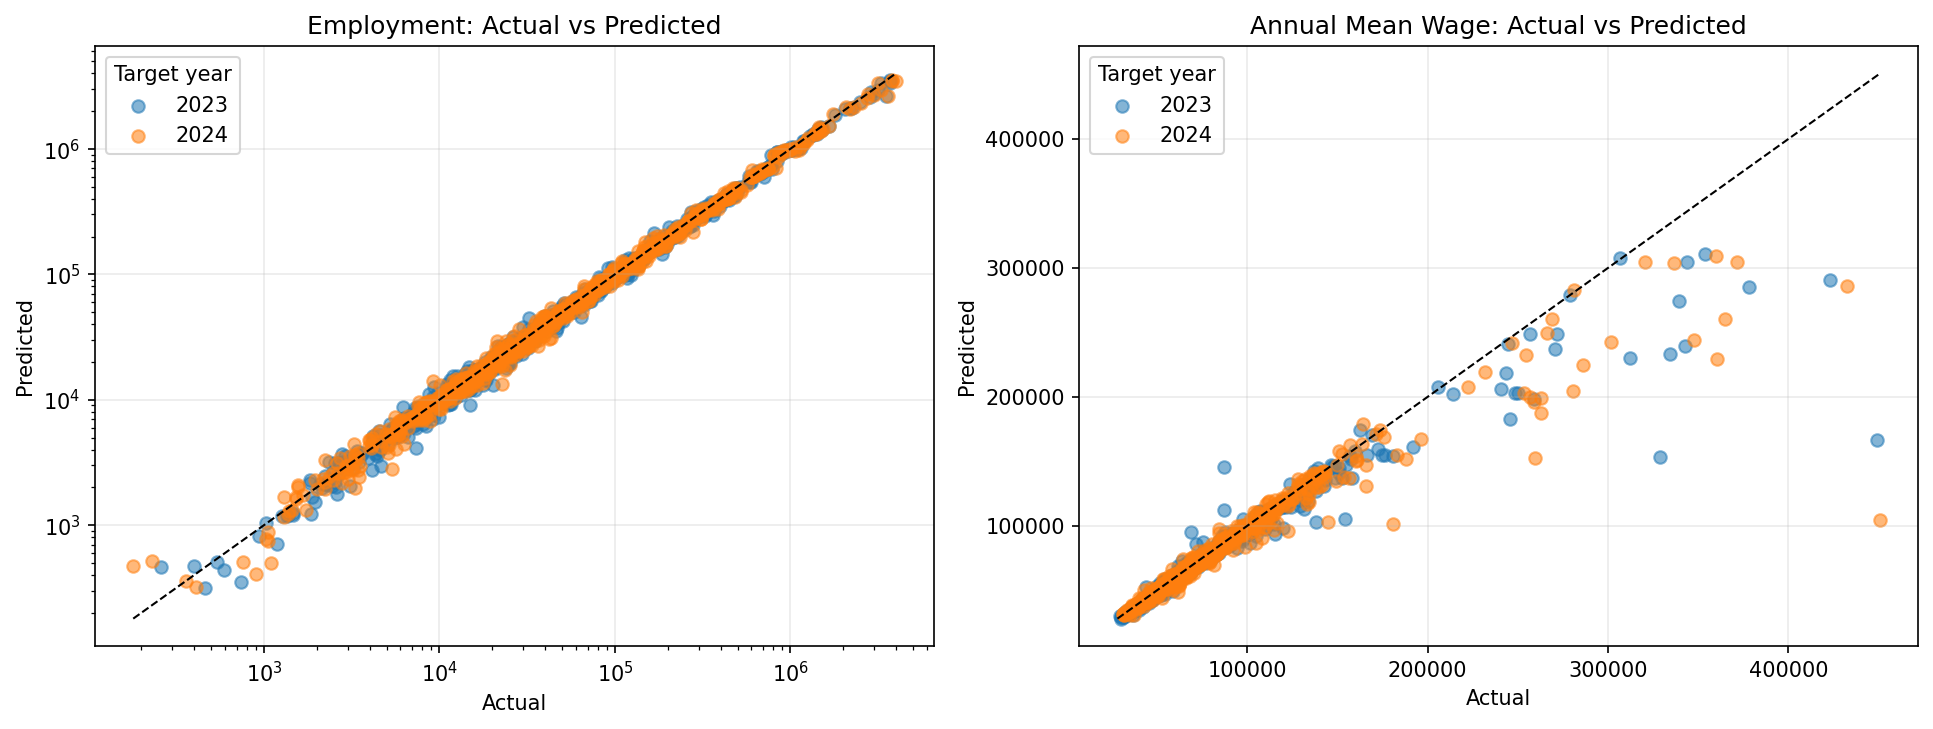

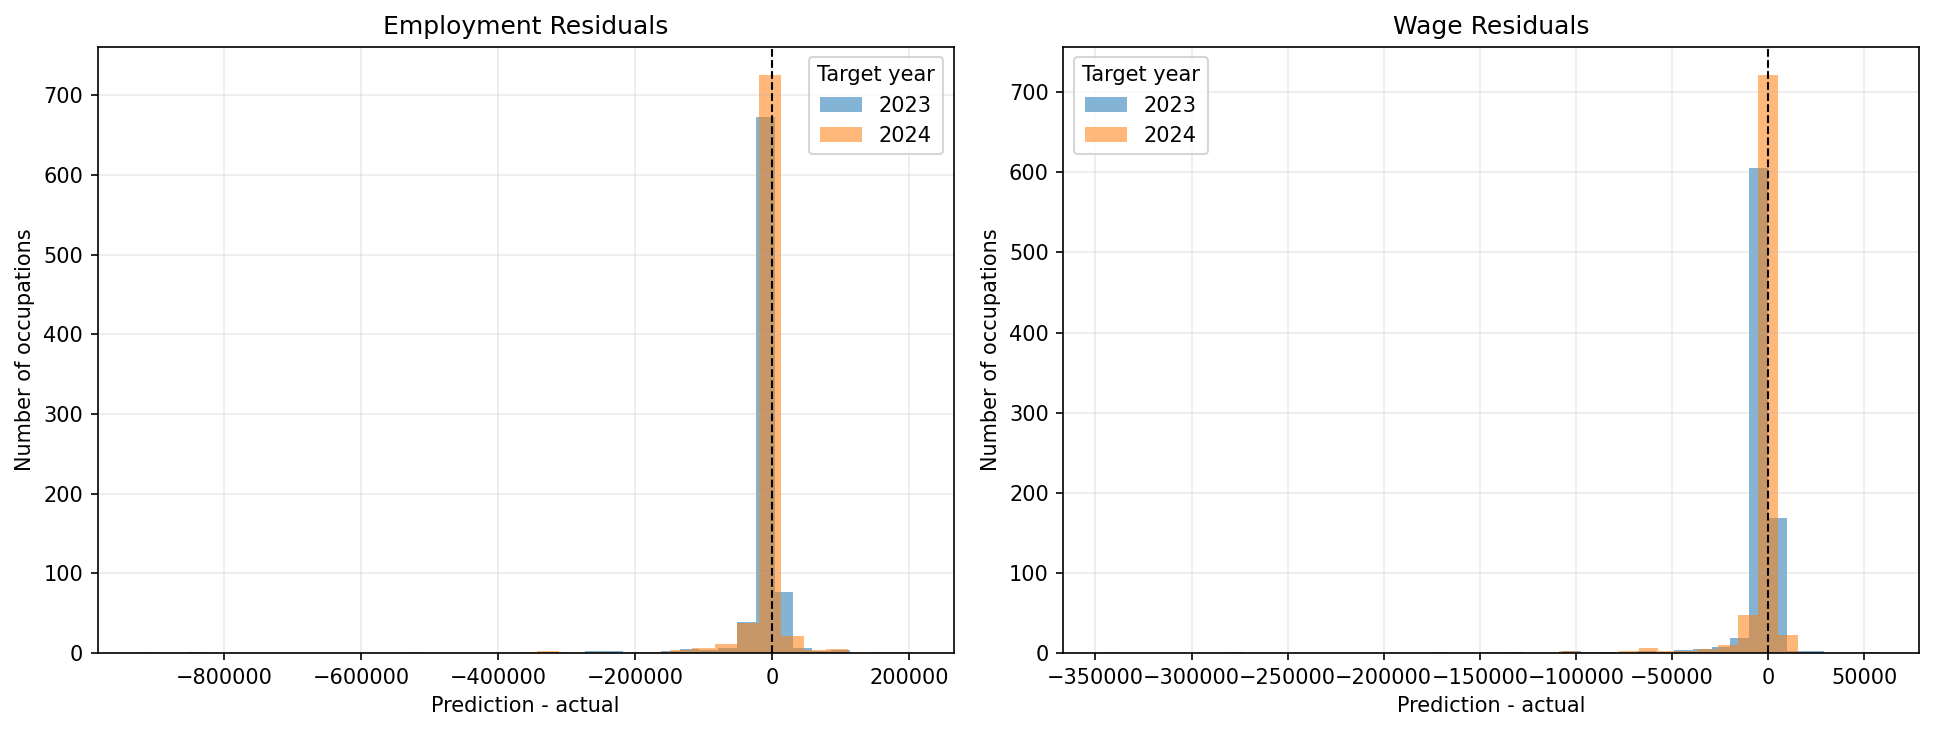

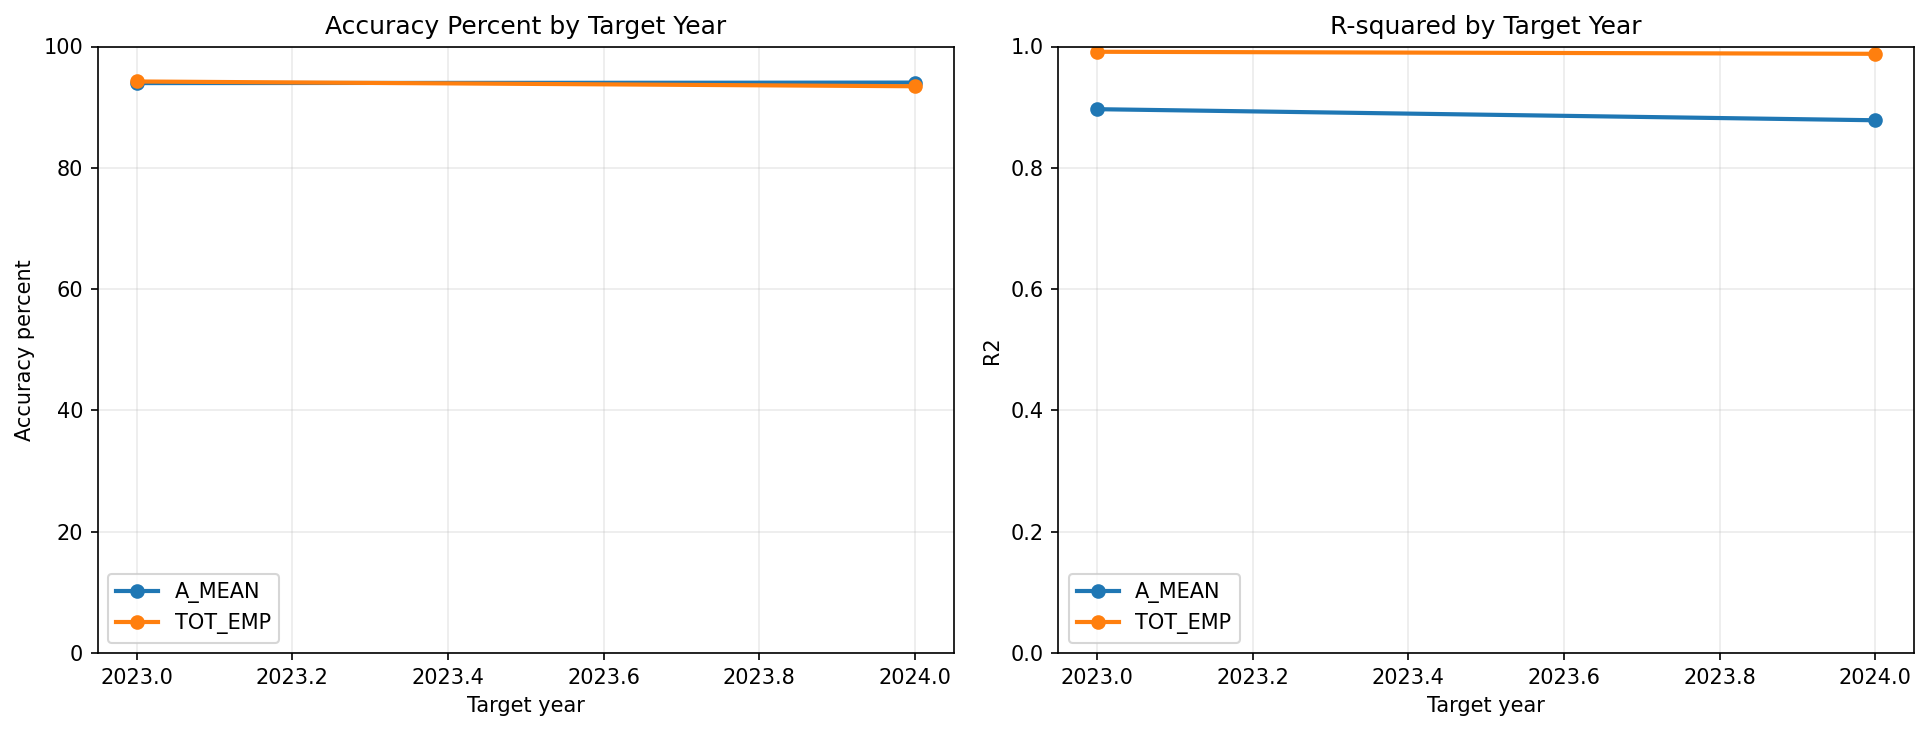

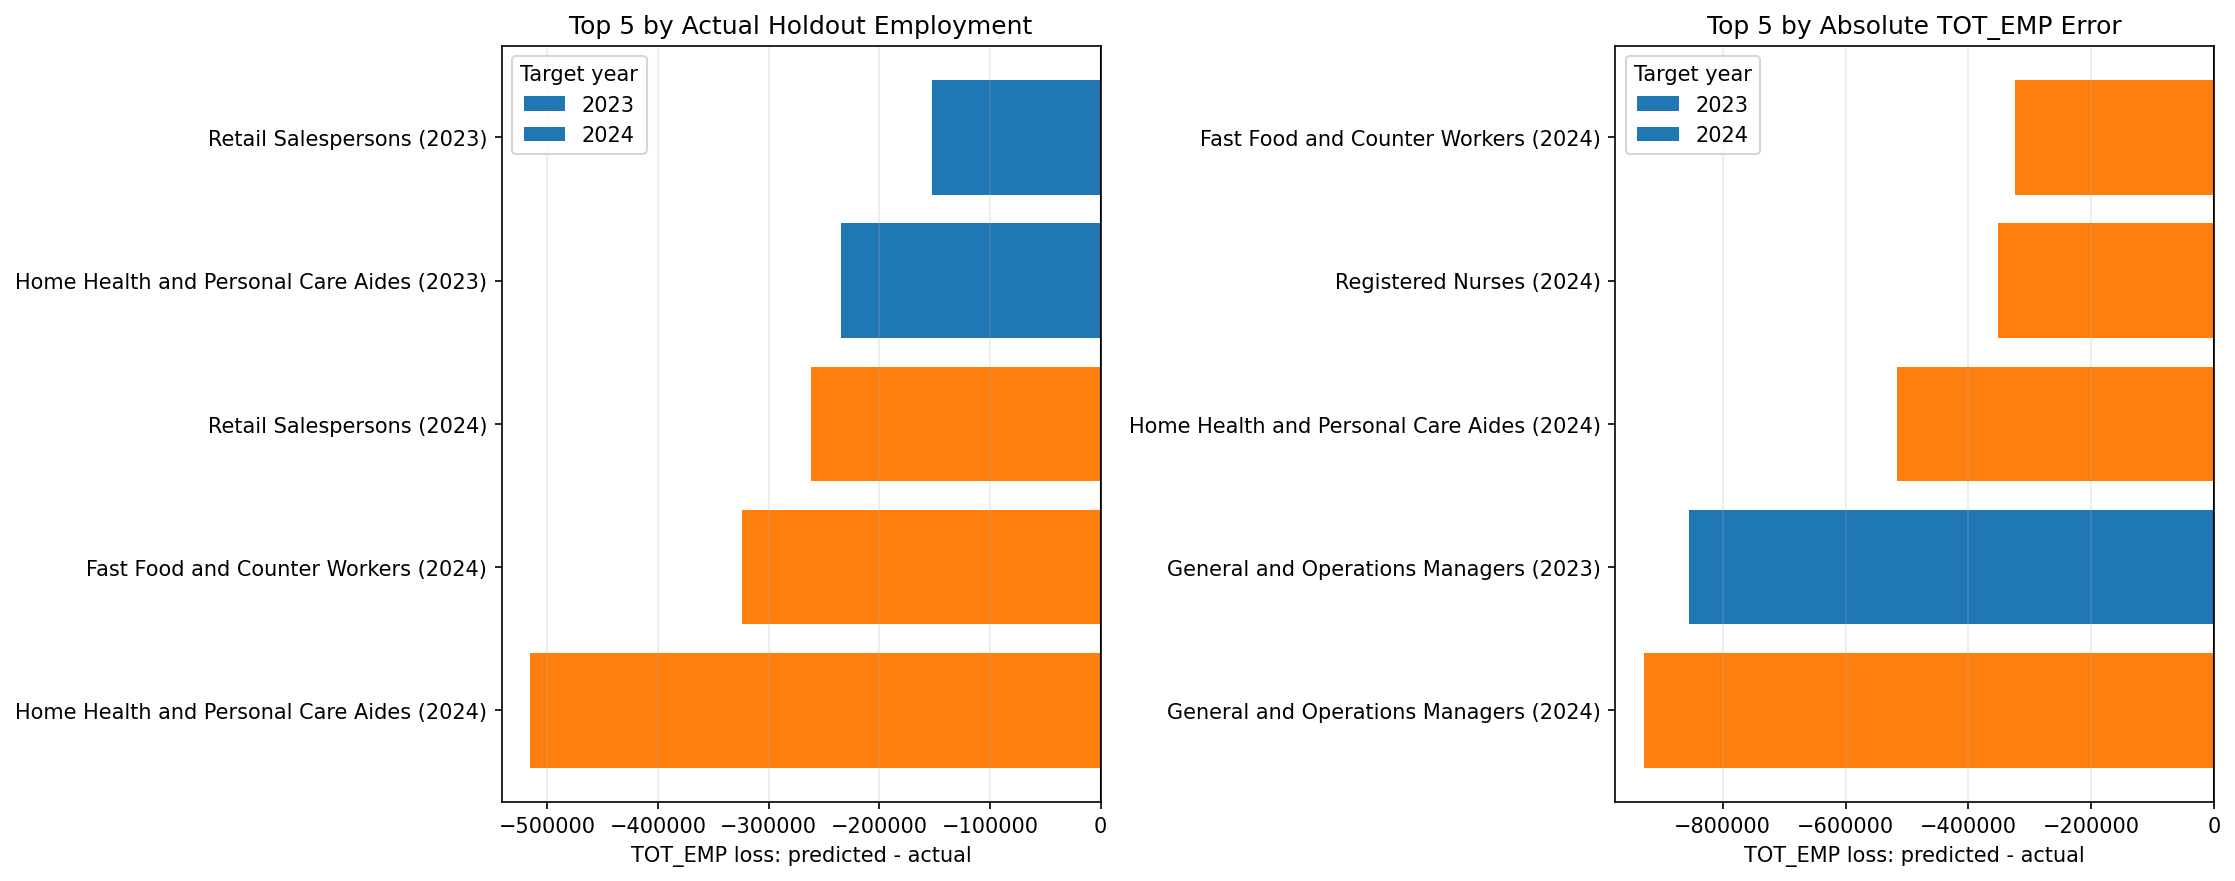

,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.472618e+06,-515521.749826
954,2024,41-2031,Retail Salespersons,3800250,3.538170e+06,-262079.543077
844,2024,35-3023,Fast Food and Counter Workers,3780930,3.456794e+06,-324135.967928
741,2023,31-1120,Home Health and Personal Care Aides,3689350,3.454873e+06,-234477.060998
953,2023,41-2031,Retail Salespersons,3684740,3.532322e+06,-152417.879835


,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
3,2024,11-1021,General and Operations Managers,3584420,2.656302e+06,-928117.924462
2,2023,11-1021,General and Operations Managers,3507810,2.653767e+06,-854043.198451
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.472618e+06,-515521.749826
640,2024,29-1141,Registered Nurses,3282010,2.930221e+06,-351788.545235
844,2024,35-3023,Fast Food and Counter Workers,3780930,3.456794e+06,-324135.967928


In [6]:
from IPython.display import Image, display

PREDICTION_YEAR_COLORS = {
    2023: "tab:blue",
    2024: "tab:orange",
}


def save_and_display(fig, filename: str) -> None:
    path = PROJECT_ROOT / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))


# 1) Actual vs. predicted plots show whether predictions track the true values.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
actual_predicted_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment", True),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Annual Mean Wage", False),
]

for ax, (_, actual_col, predicted_col, title, use_log_scale) in zip(axes, actual_predicted_specs):
    actual = predictions[actual_col]
    predicted = predictions[predicted_col]
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        ax.scatter(
            year_predictions[actual_col],
            year_predictions[predicted_col],
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")
    if use_log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()
save_and_display(fig, "model_actual_vs_predicted.png")

# 2) Residual distributions show whether errors are centered near zero.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
residual_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment Residuals"),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Wage Residuals"),
]

for ax, (_, actual_col, predicted_col, title) in zip(axes, residual_specs):
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        residual = year_predictions[predicted_col] - year_predictions[actual_col]
        ax.hist(
            residual,
            bins=35,
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Prediction - actual")
    ax.set_ylabel("Number of occupations")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "model_residual_distributions.png")

# 3) Year-by-year metrics make holdout performance easy to compare.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for target, target_metrics in metrics_by_year.groupby("target"):
    axes[0].plot(
        target_metrics["split"],
        target_metrics["ACCURACY_PERCENT"],
        marker="o",
        linewidth=2,
        label=target,
    )
    axes[1].plot(
        target_metrics["split"],
        target_metrics["R2"],
        marker="o",
        linewidth=2,
        label=target,
    )

axes[0].set_title("Accuracy Percent by Target Year")
axes[0].set_xlabel("Target year")
axes[0].set_ylabel("Accuracy percent")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("R-squared by Target Year")
axes[1].set_xlabel("Target year")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
save_and_display(fig, "model_metrics_by_year.png")

# 4) TOT_EMP loss is prediction minus actual employment for the requested top-five views.
tot_emp_loss = predictions.assign(
    TOT_EMP_LOSS=predictions["PREDICTED_TOT_EMP"] - predictions["ACTUAL_TOT_EMP"],
    ABS_TOT_EMP_LOSS=lambda data: data["TOT_EMP_LOSS"].abs(),
    OCC_YEAR_LABEL=lambda data: data["OCC_TITLE"] + " (" + data["TARGET_YEAR"].astype(str) + ")",
)

top5_by_actual_emp = tot_emp_loss.nlargest(5, "ACTUAL_TOT_EMP")
top5_by_abs_error = tot_emp_loss.nlargest(5, "ABS_TOT_EMP_LOSS")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top5_specs = [
    (top5_by_actual_emp, "Top 5 by Actual Holdout Employment"),
    (top5_by_abs_error, "Top 5 by Absolute TOT_EMP Error"),
]

for ax, (top5_data, title) in zip(axes, top5_specs):
    plot_data = top5_data.sort_values("TOT_EMP_LOSS")
    colors = [PREDICTION_YEAR_COLORS.get(int(year), "tab:gray") for year in plot_data["TARGET_YEAR"]]
    ax.barh(plot_data["OCC_YEAR_LABEL"], plot_data["TOT_EMP_LOSS"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("TOT_EMP loss: predicted - actual")
    ax.grid(axis="x", alpha=0.25)
    for target_year, color in PREDICTION_YEAR_COLORS.items():
        ax.barh([], [], color=color, label=str(target_year))
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "top5_tot_emp_loss.png")

display(
    top5_by_actual_emp[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)
display(
    top5_by_abs_error[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)

In [7]:
predictions["ABS_EMP_ERROR"] = (predictions["ACTUAL_TOT_EMP"] - predictions["PREDICTED_TOT_EMP"]).abs()
predictions["EMP_PCT_ERROR"] = predictions["ABS_EMP_ERROR"] / predictions["ACTUAL_TOT_EMP"]
predictions["ABS_WAGE_ERROR"] = (predictions["ACTUAL_A_MEAN"] - predictions["PREDICTED_A_MEAN"]).abs()
predictions["WAGE_PCT_ERROR"] = predictions["ABS_WAGE_ERROR"] / predictions["ACTUAL_A_MEAN"]

largest_emp_errors = predictions.sort_values("ABS_EMP_ERROR", ascending=False).head(15)
largest_emp_errors[[
    "OCC_CODE",
    "OCC_TITLE",
    "ACTUAL_TOT_EMP",
    "PREDICTED_TOT_EMP",
    "EMP_PCT_ERROR",
    "ACTUAL_A_MEAN",
    "PREDICTED_A_MEAN",
    "WAGE_PCT_ERROR",
]]

,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,EMP_PCT_ERROR,ACTUAL_A_MEAN,PREDICTED_A_MEAN,WAGE_PCT_ERROR
3,11-1021,General and Operations Managers,3584420,2.656302e+06,0.258931,133120,116678.375740,0.123510
2,11-1021,General and Operations Managers,3507810,2.653767e+06,0.243469,129330,115584.078158,0.106286
742,31-1120,Home Health and Personal Care Aides,3988140,3.472618e+06,0.129264,34990,30703.149881,0.122516
640,29-1141,Registered Nurses,3282010,2.930221e+06,0.107187,98430,83350.832648,0.153197
844,35-3023,Fast Food and Counter Workers,3780930,3.456794e+06,0.085729,31350,30483.341213,0.027645
1632,53-7062,"Laborers and Freight, Stock, and Material Move...",2982530,2.663142e+06,0.107086,41420,39795.531127,0.039219
843,35-3023,Fast Food and Counter Workers,3676580,3.372115e+06,0.082812,30110,29418.346668,0.022971
954,41-2031,Retail Salespersons,3800250,3.538170e+06,0.068964,37150,31093.233421,0.163035
1631,53-7062,"Laborers and Freight, Stock, and Material Move...",3008300,2.751751e+06,0.085280,39760,38236.777278,0.038310
1017,43-4051,Customer Service Representatives,2858710,2.604528e+06,0.088915,43520,40066.553870,0.079353


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
    color = PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray")
    axes[0].scatter(
        year_predictions["ACTUAL_TOT_EMP"],
        year_predictions["PREDICTED_TOT_EMP"],
        alpha=0.55,
        color=color,
        label=str(target_year),
    )
    axes[1].scatter(
        year_predictions["ACTUAL_A_MEAN"],
        year_predictions["PREDICTED_A_MEAN"],
        alpha=0.55,
        color=color,
        label=str(target_year),
    )

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Employment: Actual vs Predicted")
axes[0].set_xlabel("Actual next-year employment")
axes[0].set_ylabel("Predicted next-year employment")
axes[0].legend(title="Target year")

axes[1].set_title("Annual Mean Wage: Actual vs Predicted")
axes[1].set_xlabel("Actual next-year annual mean wage")
axes[1].set_ylabel("Predicted next-year annual mean wage")
axes[1].legend(title="Target year")

plt.tight_layout()

In [9]:
# Train on all known one-year transitions, then forecast one year beyond the latest feature year.
final_model = model
final_model.fit(model_data[available_features], model_data[TARGET_COLUMNS])

latest_year = int(panel["YEAR"].max())
latest_features = panel[panel["YEAR"].eq(latest_year)].copy()
latest_predictions_log = final_model.predict(latest_features[available_features])

next_year_forecast = pd.DataFrame(
    {
        "FORECAST_FROM_YEAR": latest_year,
        "TARGET_YEAR": latest_year + 1,
        "OCC_CODE": latest_features["OCC_CODE"].to_numpy(),
        "OCC_TITLE": latest_features["OCC_TITLE"].to_numpy(),
        "CURRENT_TOT_EMP": latest_features["TOT_EMP"].to_numpy(),
        "FORECAST_TOT_EMP": np.expm1(latest_predictions_log[:, 0]),
        "CURRENT_A_MEAN": latest_features["A_MEAN"].to_numpy(),
        "FORECAST_A_MEAN": np.expm1(latest_predictions_log[:, 1]),
    }
)
next_year_forecast["FORECAST_EMP_CHANGE"] = next_year_forecast["FORECAST_TOT_EMP"] - next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast["FORECAST_EMP_GROWTH"] = next_year_forecast["FORECAST_EMP_CHANGE"] / next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast.sort_values("FORECAST_EMP_CHANGE", ascending=False).head(20)

,FORECAST_FROM_YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,CURRENT_TOT_EMP,FORECAST_TOT_EMP,CURRENT_A_MEAN,FORECAST_A_MEAN,FORECAST_EMP_CHANGE,FORECAST_EMP_GROWTH
49,2024,2025,13-1111,Management Analysts,893900.0,9.847181e+05,114710.0,75532.641400,90818.117590,0.101598
54,2024,2025,13-1161,Market Research Analysts and Marketing Special...,861140.0,9.126880e+05,86480.0,75982.330782,51547.982034,0.059860
44,2024,2025,13-1071,Human Resources Specialists,917460.0,9.604172e+05,79730.0,70322.594142,42957.185713,0.046822
420,2024,2025,35-2021,Food Preparation Workers,888770.0,9.248895e+05,33940.0,44855.326204,36119.491976,0.040640
8,2024,2025,11-3012,Administrative Services Managers,254140.0,2.798568e+05,126030.0,132002.360554,25716.770962,0.101191
84,2024,2025,15-1299,"Computer Occupations, All Other",439380.0,4.645065e+05,116700.0,106507.006508,25126.537703,0.057186
48,2024,2025,13-1082,Project Management Specialists,1006160.0,1.027003e+06,108100.0,72572.665421,20843.361602,0.020716
53,2024,2025,13-1151,Training and Development Specialists,436610.0,4.553070e+05,73760.0,74278.620712,18696.998356,0.042823
61,2024,2025,13-2052,Personal Financial Advisors,270480.0,2.880993e+05,160210.0,167425.626842,17619.253029,0.065141
574,2024,2025,47-2073,Operating Engineers and Other Construction Equ...,469270.0,4.862532e+05,65180.0,64183.327739,16983.196936,0.036191


## Interpretation and Next Steps

The model predicts each detailed occupation's next-year employment and annual mean wage. It is a regression model, so the accuracy score is based on prediction error rather than classification correctness. The headline `ACCURACY_PERCENT` is `1 - WAPE`, meaning it measures how close the model's total absolute prediction error is to the total actual value on the 2023-2024 holdout set.

The holdout results should be treated as a backtest of one-year-ahead predictions. The final forecast cell then retrains on all known one-year transitions through 2024 and projects one year beyond the latest feature year reconstructed from the model-ready CSV.

Recommended final project workflow:

1. Compare Random Forest against simple baselines such as last-year carry-forward and linear trend.
2. Add prediction intervals or scenario ranges before presenting forecasts as decisions.
3. Report uncertainty clearly, especially for occupations affected by SOC classification changes or BLS suppression symbols.
4. Only try RNN/LSTM if you add much more frequent data, such as monthly job postings or quarterly labor-market indicators. Annual BLS files alone are too short for a reliable deep learning sequence model.